<a href="https://colab.research.google.com/github/2003Ankita/ObjectRecognizer/blob/main/part3_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: Fine-Tune a Pretrained Transformer — ViT

ImageNet-pretrained Vision Transformer fine-tuned on CIFAR-100 (resized to 224×224).  
Tries EVA-02 → BEiT → AugReg ViT → Plain ViT (best available).  
Warmup + cosine schedule, differential LR.

In [1]:
# Runtime configuration
FAST_DEV_RUN = False  # True = quick smoke test
SEED = 42

import os

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_ROOT = "/content" if IN_COLAB else os.path.abspath("./temp_student")
os.makedirs(WORK_ROOT, exist_ok=True)

DATA_ROOT = os.path.join(WORK_ROOT, "data")
OOD_DIR = os.path.join(WORK_ROOT, "ood-test-CS541")
SUBMISSION_PATH = os.path.join(WORK_ROOT, "submission_ood.csv")

print("IN_COLAB:", IN_COLAB)
print("WORK_ROOT:", WORK_ROOT)

IN_COLAB: True
WORK_ROOT: /content


In [2]:
# Install required packages
import importlib.util, subprocess, sys
required = ["torch", "torchvision", "tqdm", "numpy", "pandas", "matplotlib", "huggingface_hub", "timm"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing])
print("Environment ready")

Environment ready


In [3]:
import os, random, math, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import timm
import matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = (0.5071, 0.4867, 0.4408)  ### DO NOT CHANGE THIS
STD  = (0.2675, 0.2565, 0.2761)  ### DO NOT CHANGE THIS
USE_AMP = True

def _amp_ctx(device):
    enabled = USE_AMP and device.type == "cuda"
    try: return torch.amp.autocast(device_type=device.type, enabled=enabled)
    except (AttributeError, TypeError):
        from torch.cuda.amp import autocast; return autocast(enabled=enabled)

def _make_scaler(device):
    enabled = USE_AMP and device.type == "cuda"
    try: return torch.amp.GradScaler(device=device.type, enabled=enabled)
    except (AttributeError, TypeError):
        from torch.cuda.amp import GradScaler; return GradScaler(enabled=enabled)

set_seed(SEED)
device = get_device()
print("Device:", device)
if device.type=="cuda":
    print("GPU:", torch.cuda.get_device_name(), "| VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")
print("PyTorch:", torch.__version__)

Device: cuda
GPU: NVIDIA H100 80GB HBM3 | VRAM: 85.0 GB
PyTorch: 2.10.0+cu128


In [4]:
# ============================================================
# Data loaders (224×224 for pretrained models)
# ============================================================
def make_loaders_224(batch_size, num_workers):
    train_tfms = transforms.Compose([
        transforms.Resize(224), transforms.RandomCrop(224, padding=28),
        transforms.RandomHorizontalFlip(), transforms.TrivialAugmentWide(),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
        transforms.RandomErasing(p=0.25),
    ])
    eval_tfms = transforms.Compose([transforms.Resize(224), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    train_full = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_tfms)
    test_ds    = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tfms)
    n = len(train_full); n_tr = int(0.9*n)
    g = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(train_full, [n_tr, n-n_tr], generator=g)
    val_eval = torch.utils.data.Subset(
        datasets.CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tfms), val_ds.indices)
    if FAST_DEV_RUN:
        train_ds = torch.utils.data.Subset(train_ds, range(min(256, len(train_ds))))
        val_eval = torch.utils.data.Subset(val_eval, range(min(128, len(val_eval))))
        test_ds  = torch.utils.data.Subset(test_ds, range(min(128, len(test_ds))))
    if IN_COLAB: num_workers = 0
    pin = torch.cuda.is_available()
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin, drop_last=True),
            DataLoader(val_eval, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin))

# CutMix + MixUp
def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    W, H = x.size(2), x.size(3)
    rw, rh = int(W*np.sqrt(1-lam)), int(H*np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(cx-rw//2,0), max(cy-rh//2,0)
    x2,y2 = min(cx+rw//2,W), min(cy+rh//2,H)
    x_mix = x.clone()
    x_mix[:,:,x1:x2,y1:y2] = x[idx,:,x1:x2,y1:y2]
    lam = 1 - (x2-x1)*(y2-y1)/(W*H)
    return x_mix, y, y[idx], lam

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

In [5]:
# ============================================================
# Training engine
# ============================================================
def train_model(model, train_ld, val_ld, optimizer, scheduler, criterion, device, epochs, use_mix=True):
    history = {"train_acc":[], "val_acc":[]}
    best_va, best_st = -1.0, None
    scaler = _make_scaler(device)

    for ep in range(1, epochs+1):
        model.train(); correct=total=0
        for x, y in tqdm(train_ld, desc=f"Train {ep}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            do_mix = use_mix and random.random()<0.5
            if do_mix:
                if random.random()<0.5: x,ya,yb,lam = cutmix_data(x,y)
                else: x,ya,yb,lam = mixup_data(x,y)
            optimizer.zero_grad(set_to_none=True)
            with _amp_ctx(device):
                logits = model(x)
                if do_mix: loss = lam*criterion(logits,ya)+(1-lam)*criterion(logits,yb)
                else: loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(optimizer); scaler.update()
            correct += (logits.argmax(1)==y).sum().item(); total += y.numel()
        if scheduler: scheduler.step()
        tr_acc = correct/max(total,1)
        model.eval(); vc=vt=0
        with torch.no_grad():
            for x,y in val_ld:
                x,y=x.to(device),y.to(device)
                with _amp_ctx(device):
                    vc+=(model(x).argmax(1)==y).sum().item(); vt+=y.numel()
        va_acc = vc/max(vt,1)
        history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
        print(f"  Ep {ep:03d}/{epochs} | train {tr_acc:.4f} | val {va_acc:.4f} | lr {optimizer.param_groups[0]['lr']:.6f}")
        if va_acc > best_va: best_va=va_acc; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
    if best_st: model.load_state_dict(best_st)
    print(f"  >> Best val: {best_va:.4f}"); return history

@torch.no_grad()
def eval_acc(model, loader, device):
    model.eval(); c=t=0
    for x,y in loader:
        x,y=x.to(device),y.to(device)
        with _amp_ctx(device):
            c+=(model(x).argmax(1)==y).sum().item(); t+=y.numel()
    return 100.0*c/t

In [6]:
# ============================================================
# TRAIN Part 3: ViT pretrained, 25 epochs, 224×224
# Tries EVA-02 > BEiT > AugReg ViT > Plain ViT
# ============================================================
set_seed(SEED)
EP3 = 25 if not FAST_DEV_RUN else 2
NW = 0 if IN_COLAB else 2
print(f"\n{'='*60}\nPart 3: Best ViT — {EP3} epochs @ 224x224\n{'='*60}")
tr3, va3, te3 = make_loaders_224(32, NW)  # BS=32 fits on T4 with AMP

VIT_CANDIDATES = [
    "eva02_base_patch14_224.mim_in22k_ft_in1k",
    "beit_base_patch16_224.in22k_ft_in22k_in1k",
    "vit_base_patch16_224.augreg_in21k_ft_in1k",
    "vit_base_patch16_224",
]
model = None
for vit_name in VIT_CANDIDATES:
    try:
        print(f"  Trying: {vit_name}")
        model = timm.create_model(vit_name, pretrained=True, num_classes=100).to(device)
        print(f"  Loaded: {vit_name} ({sum(p.numel() for p in model.parameters()):,} params)")
        break
    except Exception as e:
        print(f"  Failed: {e}")
        model = None

assert model is not None, "No ViT model could be loaded!"

# Separate head vs backbone
hd_names = set()
for n, _ in model.named_parameters():
    if "head" in n or "classifier" in n: hd_names.add(n)
bb = [p for n,p in model.named_parameters() if n not in hd_names]
hd = [p for n,p in model.named_parameters() if n in hd_names]
print(f"  Head params: {hd_names}")

opt = torch.optim.AdamW([{"params":bb,"lr":2e-5},{"params":hd,"lr":1e-3}], weight_decay=0.01)
warmup_ep = 3
sch = torch.optim.lr_scheduler.LambdaLR(opt,
    lr_lambda=lambda ep: min((ep+1)/warmup_ep, 0.5*(1+math.cos(math.pi*max(0,ep-warmup_ep)/max(1,EP3-warmup_ep)))))
crit = nn.CrossEntropyLoss(label_smoothing=0.1)
hist = train_model(model, tr3, va3, opt, sch, crit, device, EP3)
acc = eval_acc(model, te3, device)
print(f"\nPart 3 Clean CIFAR-100 test accuracy: {acc:.2f}%")
torch.save(model.state_dict(), os.path.join(WORK_ROOT, "p3_vit.pt"))


Part 3: Best ViT — 25 epochs @ 224x224


100%|██████████| 169M/169M [00:04<00:00, 37.5MB/s]


  Trying: eva02_base_patch14_224.mim_in22k_ft_in1k
  Failed: Invalid pretrained tag (mim_in22k_ft_in1k) for eva02_base_patch14_224.
  Trying: beit_base_patch16_224.in22k_ft_in22k_in1k


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/350M [00:00<?, ?B/s]

...

  Ep 023/25 | train 0.7864 | val 0.9394 | lr 0.000000


Train 24/25:   0%|          | 0/1406 [00:00<?, ?it/s]

  Ep 024/25 | train 0.8033 | val 0.9406 | lr 0.000000


Train 25/25:   0%|          | 0/1406 [00:00<?, ?it/s]

  Ep 025/25 | train 0.7870 | val 0.9398 | lr 0.000000
  >> Best val: 0.9418

Part 3 Clean CIFAR-100 test accuracy: 93.88%


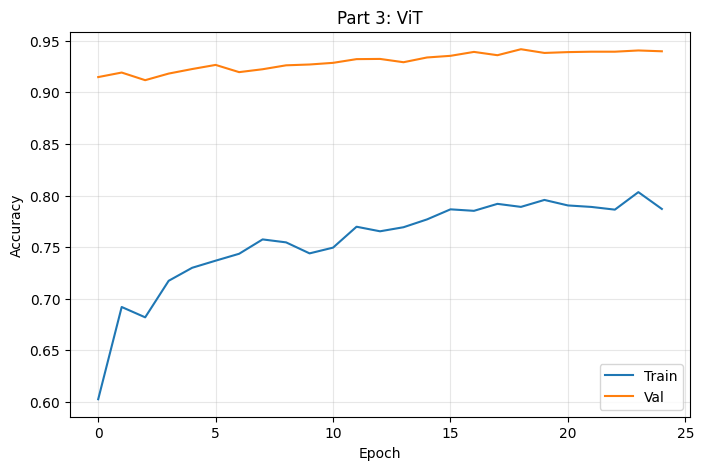

In [7]:
# Plot training curves
plt.figure(figsize=(8,5))
plt.plot(hist["train_acc"], label="Train"); plt.plot(hist["val_acc"], label="Val")
plt.title("Part 3: ViT"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## OOD Submission Generation

Submission format: `id,label`  
Using 5-view TTA (original, H-flip, center-crop, TL-crop, BR-crop).

In [8]:
### DO NOT CHANGE THE BELOW, REPLACE WITH YOUR MODEL, THE SUBMISSION FILES NEED TO GO THROUGH THE BELOW PREPROCESSING

from huggingface_hub import snapshot_download

def ensure_ood_files(ood_dir):
    os.makedirs(ood_dir, exist_ok=True)
    print("Downloading OOD files from Hugging Face dataset...")
    snapshot_download(repo_id="XThomasBU/ood-test-CS541", repo_type="dataset",
                      local_dir=ood_dir, local_dir_use_symlinks=False)
    print("OOD files ready in", ood_dir)

@torch.no_grad()
def get_tta_probs(model, xb, device):
    model.eval()
    h, w = xb.shape[2], xb.shape[3]
    margin = max(2, h // 16)
    probs = torch.zeros(xb.size(0), 100)
    with _amp_ctx(device): probs += F.softmax(model(xb.to(device)).float().cpu(), dim=1)
    with _amp_ctx(device): probs += F.softmax(model(xb.flip(-1).to(device)).float().cpu(), dim=1)
    c = F.interpolate(xb[:,:,margin:h-margin,margin:w-margin], size=(h,w), mode="bilinear", align_corners=False)
    with _amp_ctx(device): probs += F.softmax(model(c.to(device)).float().cpu(), dim=1)
    tl = F.interpolate(xb[:,:,:h-margin*2,:w-margin*2], size=(h,w), mode="bilinear", align_corners=False)
    with _amp_ctx(device): probs += F.softmax(model(tl.to(device)).float().cpu(), dim=1)
    br = F.interpolate(xb[:,:,margin*2:,margin*2:], size=(h,w), mode="bilinear", align_corners=False)
    with _amp_ctx(device): probs += F.softmax(model(br.to(device)).float().cpu(), dim=1)
    return probs / 5.0

@torch.no_grad()
def predict_file(model, npy_path, severity, batch_size):
    images = np.load(npy_path, mmap_mode="r")
    start, end = (severity-1)*10000, severity*10000
    mean_t = torch.tensor(MEAN).view(1,3,1,1)
    std_t  = torch.tensor(STD).view(1,3,1,1)
    all_preds = []
    for b0 in range(start, end, batch_size):
        b1 = min(b0+batch_size, end)
        xb = torch.from_numpy(np.array(images[b0:b1], copy=True)).permute(0,3,1,2).float().div(255.0)
        xb = (xb - mean_t) / std_t
        # Resize to 224 for pretrained ViT
        xb = F.interpolate(xb, 224, mode="bilinear", align_corners=False)
        all_preds.append(get_tta_probs(model, xb, device).argmax(1).numpy())
    return np.concatenate(all_preds)

ensure_ood_files(OOD_DIR)
distortion_files = sorted([p for p in os.listdir(OOD_DIR) if p.startswith("distortion") and p.endswith(".npy")])
print(f"Distortion files: {len(distortion_files)}")

BATCH = 16 if device.type=="cuda" else 4  # smaller batch for ViT + TTA
rows = []
for fi, fname in enumerate(distortion_files):
    dname = os.path.splitext(fname)[0]
    path = os.path.join(OOD_DIR, fname)
    for sev in [1,2,3,4,5]:
        pred = predict_file(model, path, sev, BATCH)
        for i, y in enumerate(pred.tolist()):
            rows.append((f"{dname}_{sev}_{i}", int(y)))
    print(f"  [{fi+1}/{len(distortion_files)}] {dname} done")

submission = pd.DataFrame(rows, columns=["id", "label"])
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nWrote {SUBMISSION_PATH} ({len(submission)} rows)")
print(submission.head())

if IN_COLAB:
    try: from google.colab import files; files.download(SUBMISSION_PATH)
    except: print("Download manually:", SUBMISSION_PATH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

OOD files ready in /content/ood-test-CS541
Distortion files: 20
  [1/20] distortion00 done
  [2/20] distortion01 done
  [3/20] distortion02 done
  [4/20] distortion03 done
  [5/20] distortion04 done
  [6/20] distortion05 done
  [7/20] distortion06 done
  [8/20] distortion07 done
  [9/20] distortion08 done
  [10/20] distortion09 done
  [11/20] distortion10 done
  [12/20] distortion11 done
  [13/20] distortion12 done
  [14/20] distortion13 done
  [15/20] distortion14 done
  [16/20] distortion15 done
  [17/20] distortion16 done
  [18/20] distortion17 done
  [19/20] distortion18 done
  [20/20] distortion_19 done

Wrote /content/submission_ood.csv (1000000 rows)
                 id  label
0  distortion00_1_0     68
1  distortion00_1_1     33
2  distortion00_1_2     72
3  distortion00_1_3     51
4  distortion00_1_4     71


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>